In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [3]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [4]:
df_train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
df_test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
test_ids = df_test.PassengerId

In [5]:
print("Checking number of Missing data for each column\n")
for col in df_train.columns:
    print(f"missing data of {col}: {df_train[col].isnull().sum()}")
print("-----------------------------------------------------------------------------\n")

#looking columns' info
print(df_train.info())

print("-----------------------------------------------------------------------------\n")

#insigh of the data
print(df_train.describe())

print("-----------------------------------------------------------------------------\n")

Checking number of Missing data for each column

missing data of PassengerId: 0
missing data of Survived: 0
missing data of Pclass: 0
missing data of Name: 0
missing data of Sex: 0
missing data of Age: 177
missing data of SibSp: 0
missing data of Parch: 0
missing data of Ticket: 0
missing data of Fare: 0
missing data of Cabin: 687
missing data of Embarked: 2
-----------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    o

In [6]:
df_test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
#We will drop the Passenger Id since it's not related with the survival
df_test_Id = df_test.copy()
df_train = df_train.drop(columns=["PassengerId", "Name", "Ticket", "Embarked"])
df_test = df_test.drop(columns=["PassengerId", "Name", "Ticket", "Embarked"])


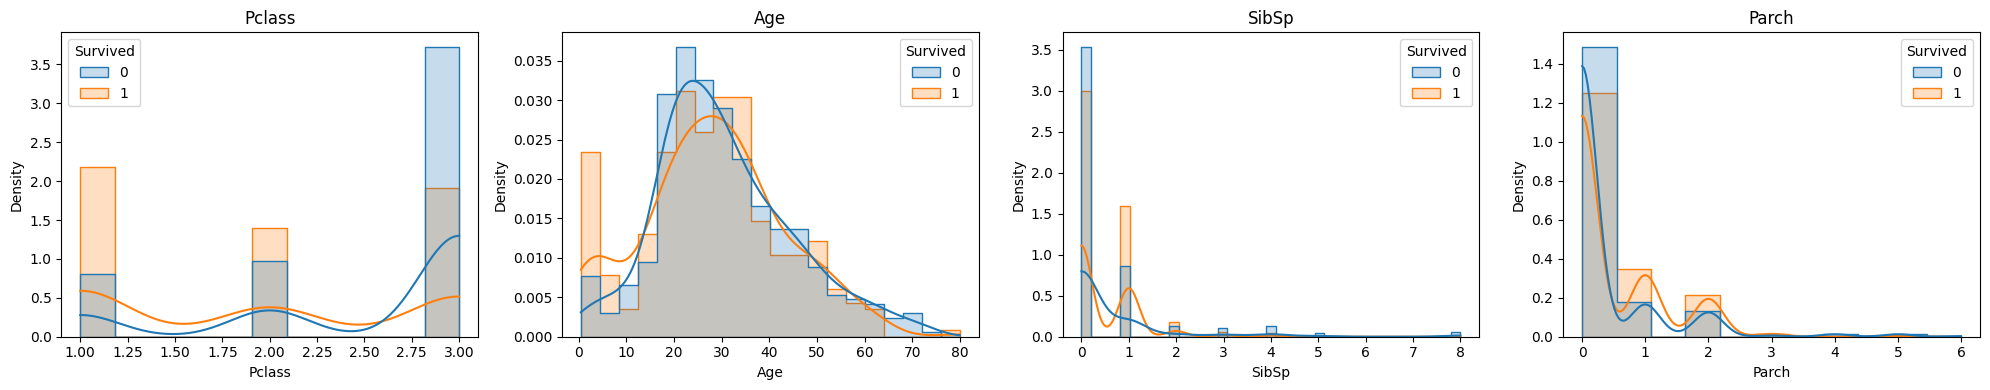

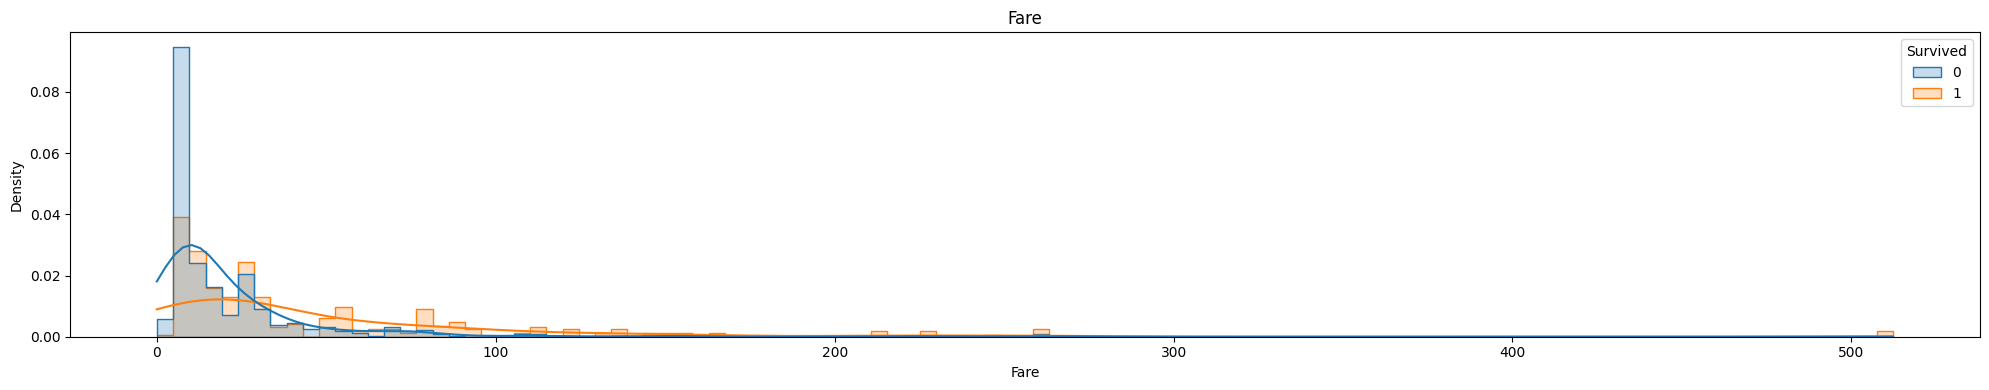

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

num_features = df_train.select_dtypes(include=["int64", "float"]).columns
num_features = [c for c in num_features if c != "Survived"]

plots_per_row = 4

for i in range(0, len(num_features), plots_per_row):
    subset = num_features[i:i+plots_per_row]

    fig, axes = plt.subplots(1, len(subset), figsize=(20, 4))

    if len(subset) == 1:
        axes = [axes]

    for ax, feature in zip(axes, subset):
        sns.histplot(
            data=df_train,
            x=feature,
            hue="Survived",
            kde=True,
            element="step",
            stat="density",
            common_norm=False,
            ax=ax
        )
        ax.set_title(feature)

    plt.tight_layout()
    plt.show()

In [9]:
X_train_c= df_train.copy()
nominated_cols = ["Pclass", "Sex", "Age", "Parch", "Fare", "Cabin"]
X_train_copy = X_train_c[nominated_cols]

for col in X_train_copy.columns:
    unique_value_count = df_train[col].unique()
    print(f"{col} different data entry: {unique_value_count}")
    print("-------------------------------------------------------")


Pclass different data entry: [3 1 2]
-------------------------------------------------------
Sex different data entry: ['male' 'female']
-------------------------------------------------------
Age different data entry: [22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.  ]
-------------------------------------------------------
Parch different data entry: [0 1 2 5 3 4 6]
-------------------------------------------------------
Fare different data entry: [  7.25    71.2833   7.925   53.1      8.05     8.4583  51.8625  21.0

Since there is noticabile amount of missing data in the Cabin column, and it still an important feature in deciding who survived in the incident

In [10]:
def impute(X: pd.DataFrame, cat_imputer = None, num_imputer = None) -> pd.DataFrame:
    X = X.copy()
    cat_cols = X.select_dtypes(include=["object", "category"]).columns
    num_cols = X.select_dtypes(exclude=["object", "category"]).columns

    #categorical cols
    if cat_imputer is None:
        cat_imputer = SimpleImputer(strategy="most_frequent")  
        X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])
    else:
        X[cat_cols] = cat_imputer.transform(X[cat_cols])

    #numerical cols
    if num_imputer is None:
        num_imputer = SimpleImputer(strategy="mean")
        X[num_cols] = num_imputer.fit_transform(X[num_cols])
    else:
        X[num_cols] = num_imputer.transform(X[num_cols])

    
    return X, cat_imputer, num_imputer

In [11]:
X_train = df_train.copy()
X_train, cat_imputer, num_imputer = impute(X_train)

In [12]:
X_train2 = df_train.copy()
X_train2, cat_imputer, num_imputer = impute(X_train, cat_imputer, num_imputer)

In [13]:
#Creating new features out of Cabin column and we will be making a method for this since we will need again
#for the test data

def creating_new_feature_from_cabin(X: pd.DataFrame) -> pd.DataFrame:
    X_train = X.copy()
    X_train["hasCabin"] = X_train.Cabin.notnull().astype("int")
    X_train["Deck"] = [X_train.Cabin.astype("str")[i][0] for i in range(len(X_train.Cabin))]
    X_train["Deck"] = X_train["Deck"].replace("n", "Unknown")
    X_train = X_train.drop(columns="Cabin")
    return X_train

In [14]:
#X_train["familySize"] = (X_train.SibSp + X_train.Parch) + 1
#X_train.familySize.unique()
#X_train = X_train.drop(columns=["SibSp", "Parch"])

In [15]:
#X_train.columns

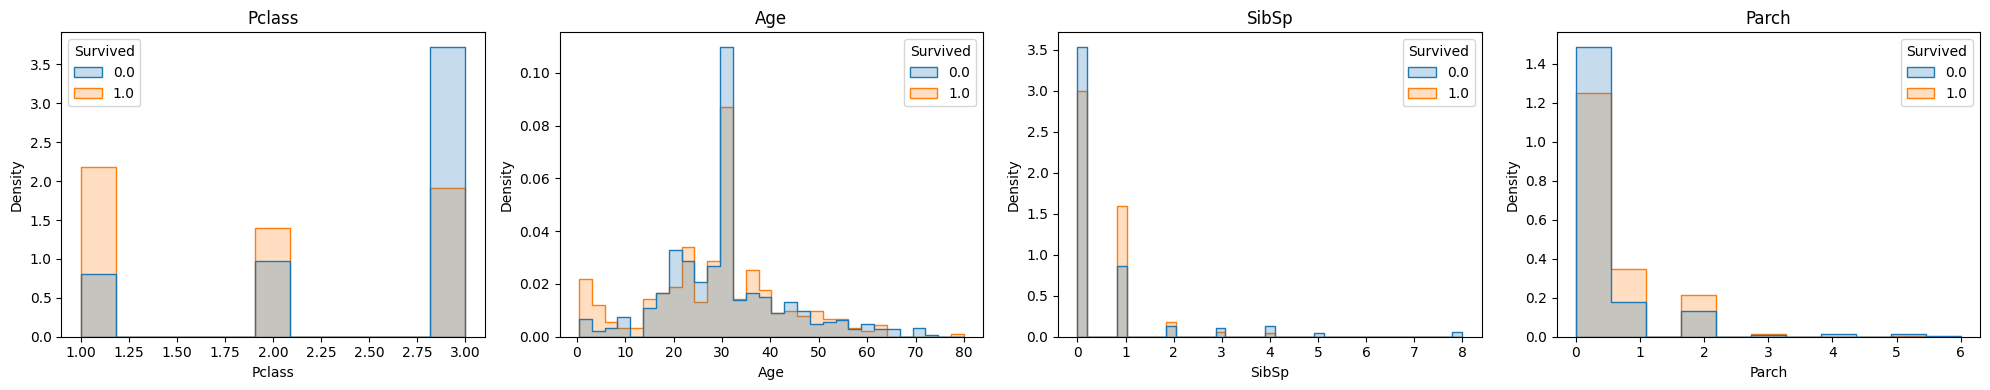

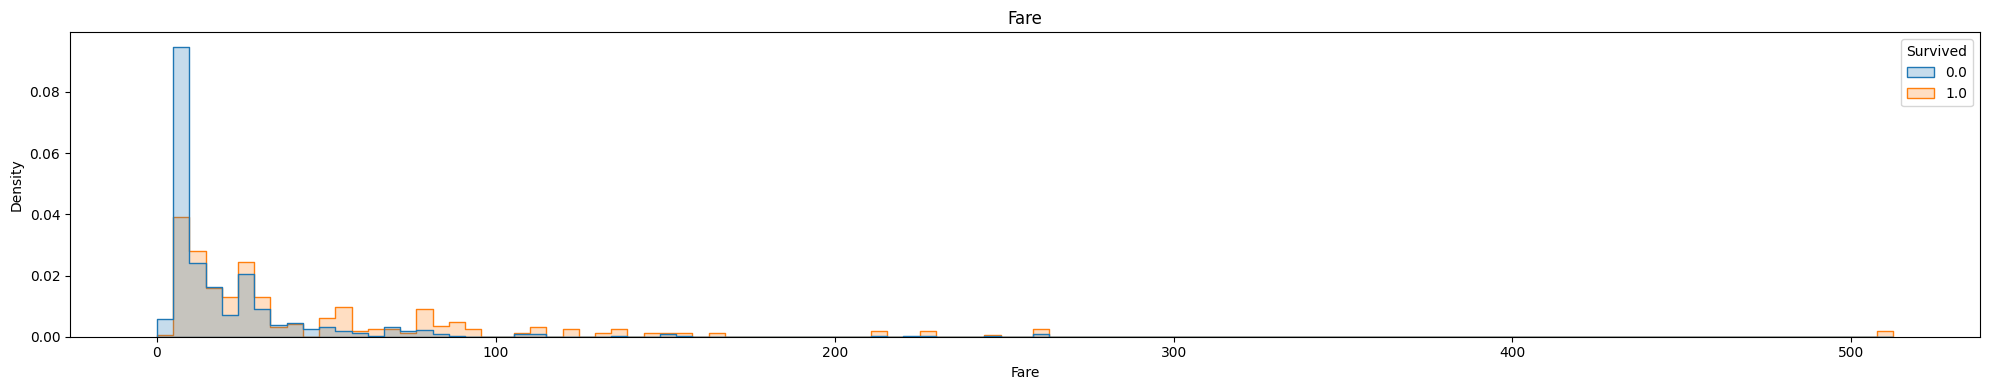

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

num_features = X_train.select_dtypes(include=["int64", "float"]).columns
num_features = [c for c in num_features if c != "Survived"]

plots_per_row = 4

for i in range(0, len(num_features), plots_per_row):
    subset = num_features[i:i+plots_per_row]

    fig, axes = plt.subplots(1, len(subset), figsize=(20, 4))

    if len(subset) == 1:
        axes = [axes]

    for ax, feature in zip(axes, subset):
        sns.histplot(
            data=X_train,
            x=feature,
            hue="Survived",
            kde=False,
            element="step",
            stat="density",
            common_norm=False,
            ax=ax
        )
        ax.set_title(feature)

    plt.tight_layout()
    plt.show()

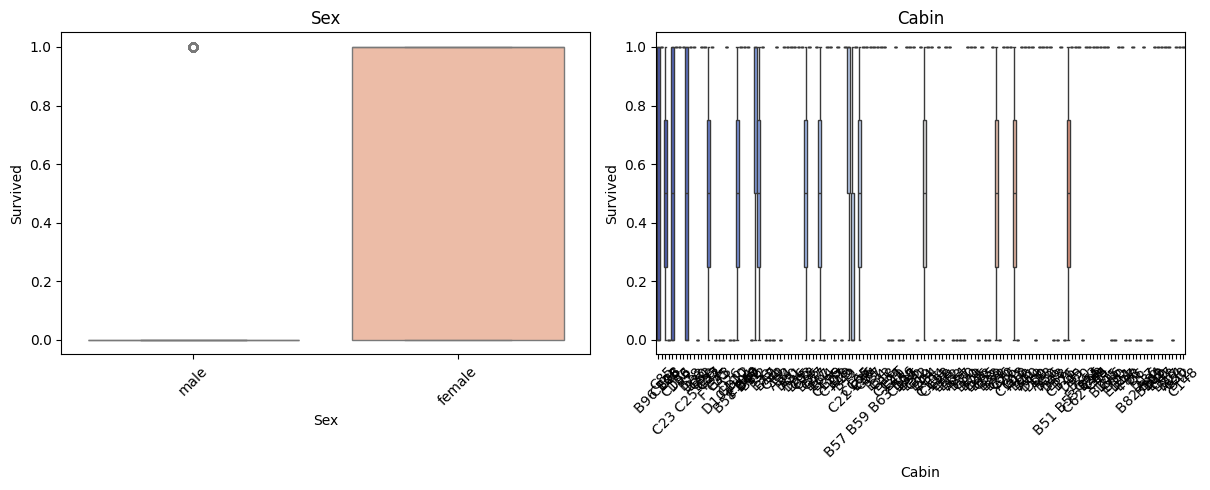

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cat_features = X_train.select_dtypes(include=["object", "category"]).columns

n_cols = 3
n_rows = math.ceil(len(cat_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    sns.boxplot(
    x=feature,
    y="Survived",
    data=X_train,
    hue=feature,        
    palette="coolwarm",
    ax=axes[i],
    legend=False         
)
    axes[i].set_title(feature)
    axes[i].tick_params(axis='x', rotation=45)

# remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [18]:
from sklearn.preprocessing import OneHotEncoder
def encode(X, ohe=None):
    X = X.copy()

    nominal_cols = X.select_dtypes(include=["object", "category"]).columns

    if ohe is None:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        encoded = ohe.fit_transform(X[nominal_cols])
    else:
        encoded = ohe.transform(X[nominal_cols])

    encoded_df = pd.DataFrame(
        encoded,
        columns=ohe.get_feature_names_out(nominal_cols),
        index=X.index
    )

    X = X.drop(columns=nominal_cols)
    X = pd.concat([X, encoded_df], axis=1)

    return X, ohe

In [19]:
def preprocessing(X, ohe=None, cat_imputer=None, num_imputer=None):

    X = X.copy()

    if cat_imputer is None or num_imputer is None:
            #preprocess
            X, cat_imputer, num_imputer = impute(X)
    else:
        X, cat_imputer, num_imputer = impute(X, cat_imputer, num_imputer)
        
    #creating new feature out of Cabin
    X = creating_new_feature_from_cabin(X)
        

    #Creating new feature "familySize", and drop old features
    X["familySize"] = (X.SibSp + X.Parch) + 1
    X.familySize.unique()
    X = X.drop(columns=["SibSp", "Parch"])

    if ohe is None:
        X, ohe = encode(X)
    else:
        X, ohe = encode(X, ohe)
        
    return X, ohe, cat_imputer, num_imputer

In [20]:
X_1 = df_train.copy()
y = df_train["Survived"]
X_1 = X_1.drop(columns="Survived")
X_2 = df_test.copy()

X_1, train_ohe, train_cat_imputer, train_num_imputer = preprocessing(X_1)
X_2, train_ohe, train_cat_imputer, train_num_imputer = preprocessing(X_2, train_ohe, train_cat_imputer, train_num_imputer)

In [21]:
X_1

,Pclass,Age,Fare,hasCabin,familySize,Sex_female,Sex_male,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T
0,3.0,22.000000,7.2500,1,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,38.000000,71.2833,1,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3.0,26.000000,7.9250,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,35.000000,53.1000,1,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,3.0,35.000000,8.0500,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2.0,27.000000,13.0000,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
887,1.0,19.000000,30.0000,1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
888,3.0,29.699118,23.4500,1,4.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
889,1.0,26.000000,30.0000,1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [23]:
# 1. Import libraries
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 2. (Optional but recommended) split training data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_1, y, test_size=0.2, random_state=42
)

# 3. Create model
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.6,
    random_state=42,
    eval_metric="logloss"
)


# 4. Train model
model.fit(X_train, y_train)

# 5. Validate
y_pred_val = model.predict(X_val)
acc = accuracy_score(y_val, y_pred_val)

print("Validation Accuracy:", acc)

# 6. Train on FULL data (important for Kaggle)
model.fit(X_1, y)

# 7. Predict test data
y_pred_test = model.predict(X_2)

# 8. (Optional) If you need probabilities
y_prob_test = model.predict_proba(X_2)[:, 1]

Validation Accuracy: 0.8156424581005587


In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,  
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_1, y)

print("Best Params:", random_search.best_params_)

Best Params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


In [25]:
import pandas as pd

submission = pd.DataFrame({
    "PassengerId": test_ids, 
    "Survived": y_pred_test
})

submission.to_csv("submission.csv", index=False)